# Segmentasi Profil Kesehatan Pasien — Studi Kasus Unsupervised Learning

**Mata Kuliah:** Fundamental Sains Data
**Studi Kasus:** Unsupervised Learning — Clustering
**Dataset:** Diabetes Clinical Dataset (Vanderbilt University Diabetes Dataset)

Notebook ini membahas proses lengkap analisis data untuk **mengelompokkan (clustering) pasien**
berdasarkan profil kesehatan (kolesterol, gula darah, tekanan darah, ukuran tubuh, dsb.) tanpa
menggunakan label, mulai dari deskripsi dataset, EDA, preprocessing, pemilihan algoritma clustering,
evaluasi, hingga insight dan kesimpulan.


## 1. Deskripsi Dataset

**Nama dataset:** Diabetes Dataset (Vanderbilt University Biostatistics)

**Sumber dataset:** Dataset ini dikumpulkan oleh Dr. John Schorling dari Departemen Kedokteran
Universitas Virginia mengenai studi prevalensi diabetes, obesitas, dan faktor risiko kardiovaskular
lain di sekitar Virginia. Dataset dipublikasikan secara terbuka melalui Vanderbilt University's
Department of Biostatistics dan juga tersedia di berbagai open dataset repository (mis. Kaggle
sebagai *"Diabetes Dataset"*).

**Jumlah data (sebelum pembersihan):** 403 baris (pasien)

**Jumlah fitur (awal):** 19 kolom, sebagian besar merupakan hasil pemeriksaan medis dan atribut
demografis pasien.

**Penjelasan fitur penting:**
| Fitur | Deskripsi |
|---|---|
| chol | Kadar kolesterol total |
| stab.glu | Kadar glukosa darah stabil (stabilized glucose) |
| hdl | Kadar kolesterol HDL ("kolesterol baik") |
| ratio | Rasio kolesterol total terhadap HDL |
| glyhb | Kadar glycosylated hemoglobin (HbA1c) — indikator gula darah jangka panjang |
| age | Usia pasien |
| gender | Jenis kelamin |
| height, weight | Tinggi (inch) dan berat badan (pound) |
| frame | Ukuran kerangka tubuh (small/medium/large) |
| bp.1s, bp.1d | Tekanan darah sistolik & diastolik (pengukuran pertama) |
| waist, hip | Lingkar pinggang dan pinggul |
| location | Lokasi pengambilan data (Buckingham/Louisa) |

Kolom `bp.2s` dan `bp.2d` (pengukuran tekanan darah kedua) memiliki >60% data hilang sehingga akan
dibuang pada tahap preprocessing. Kolom `id` merupakan pengenal unik pasien, bukan fitur analitis.

**Fitur yang digunakan untuk menemukan pola/kelompok data:** `chol`, `stab.glu`, `hdl`, `ratio`,
`glyhb`, `age`, `height`, `weight`, `bp.1s`, `bp.1d`, `waist`, `hip`, serta `gender` dan `frame`
(setelah encoding).

**Tujuan analisis:** Mengelompokkan pasien ke dalam beberapa segmen/klaster berdasarkan profil
kesehatan (kolesterol, gula darah, tekanan darah, dan ukuran tubuh) untuk mengidentifikasi kelompok
pasien dengan karakteristik risiko kesehatan yang serupa (misalnya kelompok dengan risiko metabolik
tinggi vs rendah), tanpa menggunakan label diagnosis sebelumnya.


In [1]:
# Import library yang digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load dataset
df = pd.read_csv('data/diabetes_unsupervised.csv')
print('Ukuran dataset:', df.shape)
df.head()


Ukuran dataset: (403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    str    
 7   age       403 non-null    int64  
 8   gender    403 non-null    str    
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    str    
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), str(3)
memory usage: 59.9 KB


In [4]:
df.isna().sum().sort_values(ascending=False)


bp.2d       262
bp.2s       262
glyhb        13
frame        12
bp.1s         5
bp.1d         5
height        5
time.ppn      3
waist         2
hip           2
chol          1
weight        1
ratio         1
hdl           1
id            0
stab.glu      0
age           0
location      0
gender        0
dtype: int64

## 2. Exploratory Data Analysis (EDA) dan Visualisasi Data


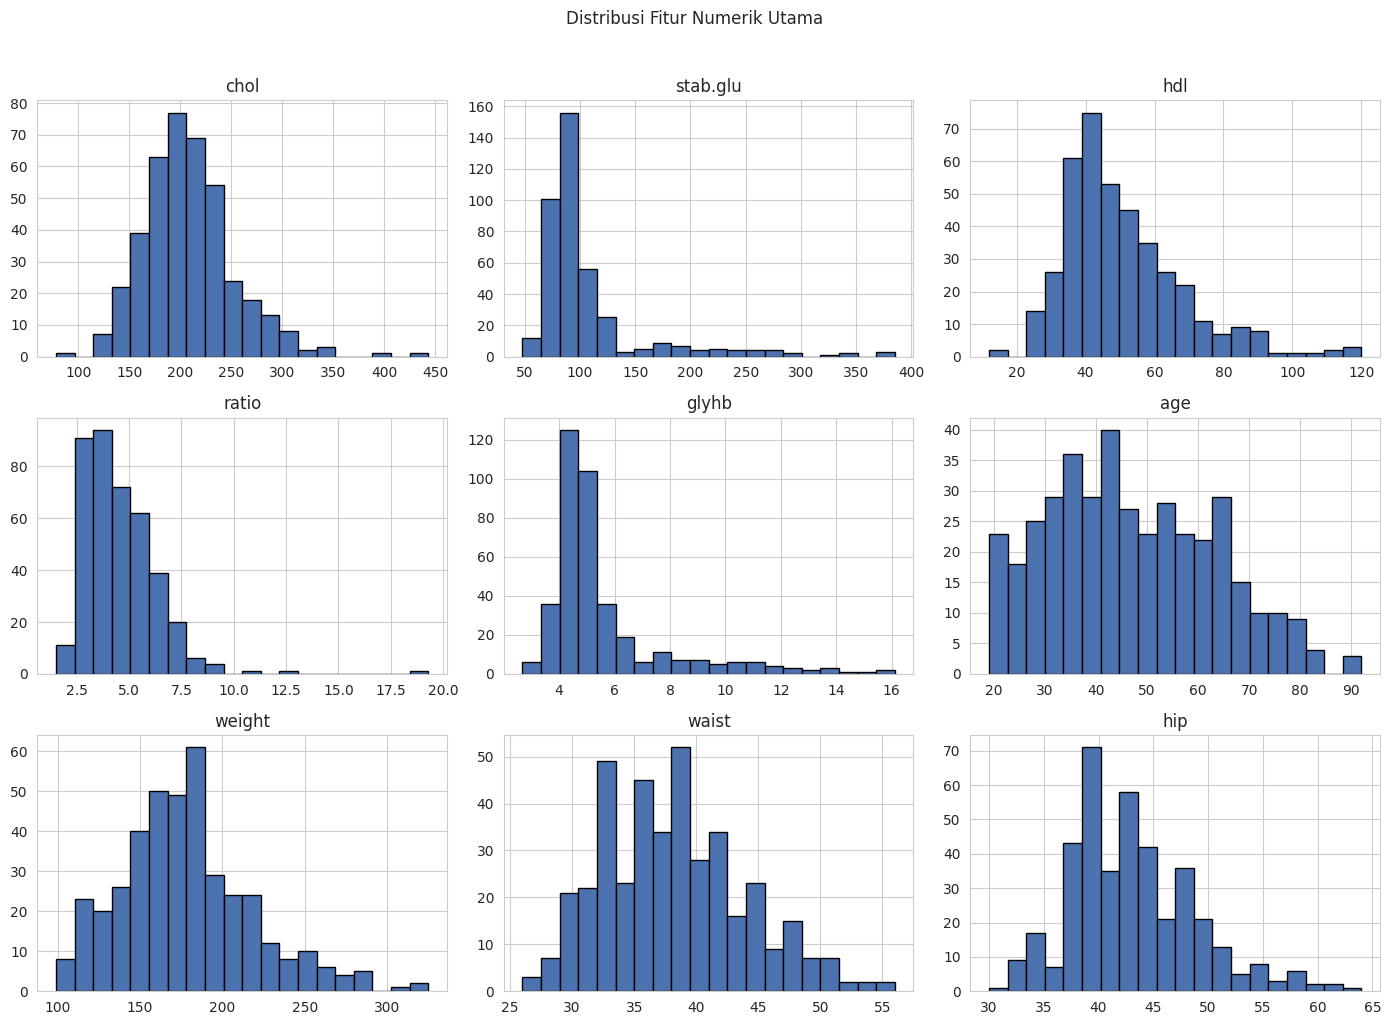

In [5]:
# Distribusi fitur numerik utama
num_cols_preview = ['chol','stab.glu','hdl','ratio','glyhb','age','weight','waist','hip']
df[num_cols_preview].hist(bins=20, figsize=(14,10), color='#4C72B0', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik Utama', y=1.02)
plt.tight_layout()
plt.show()


**Insight:** Sebagian besar fitur seperti `chol`, `stab.glu`, dan `glyhb` (HbA1c) memiliki
distribusi right-skewed dengan beberapa nilai ekstrem tinggi — mengindikasikan adanya sekelompok
kecil pasien dengan kadar gula darah / kolesterol jauh di atas rata-rata, yang berpotensi menjadi
salah satu klaster dengan risiko kesehatan tinggi.


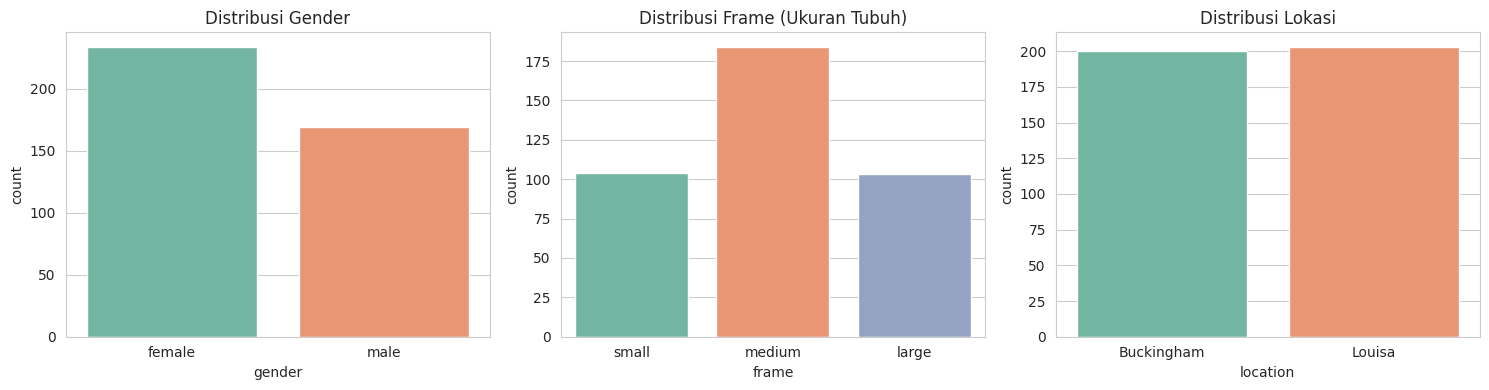

In [6]:
# Distribusi kategori: gender dan frame
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(x='gender', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Gender')
sns.countplot(x='frame', data=df, ax=axes[1], palette='Set2', order=['small','medium','large'])
axes[1].set_title('Distribusi Frame (Ukuran Tubuh)')
sns.countplot(x='location', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Distribusi Lokasi')
plt.tight_layout()
plt.show()


**Insight:** Jumlah pasien wanita sedikit lebih banyak dibanding pria, mayoritas pasien memiliki
ukuran kerangka tubuh (`frame`) medium, dan data terdistribusi cukup merata antara dua lokasi
pengambilan sampel (Buckingham dan Louisa).


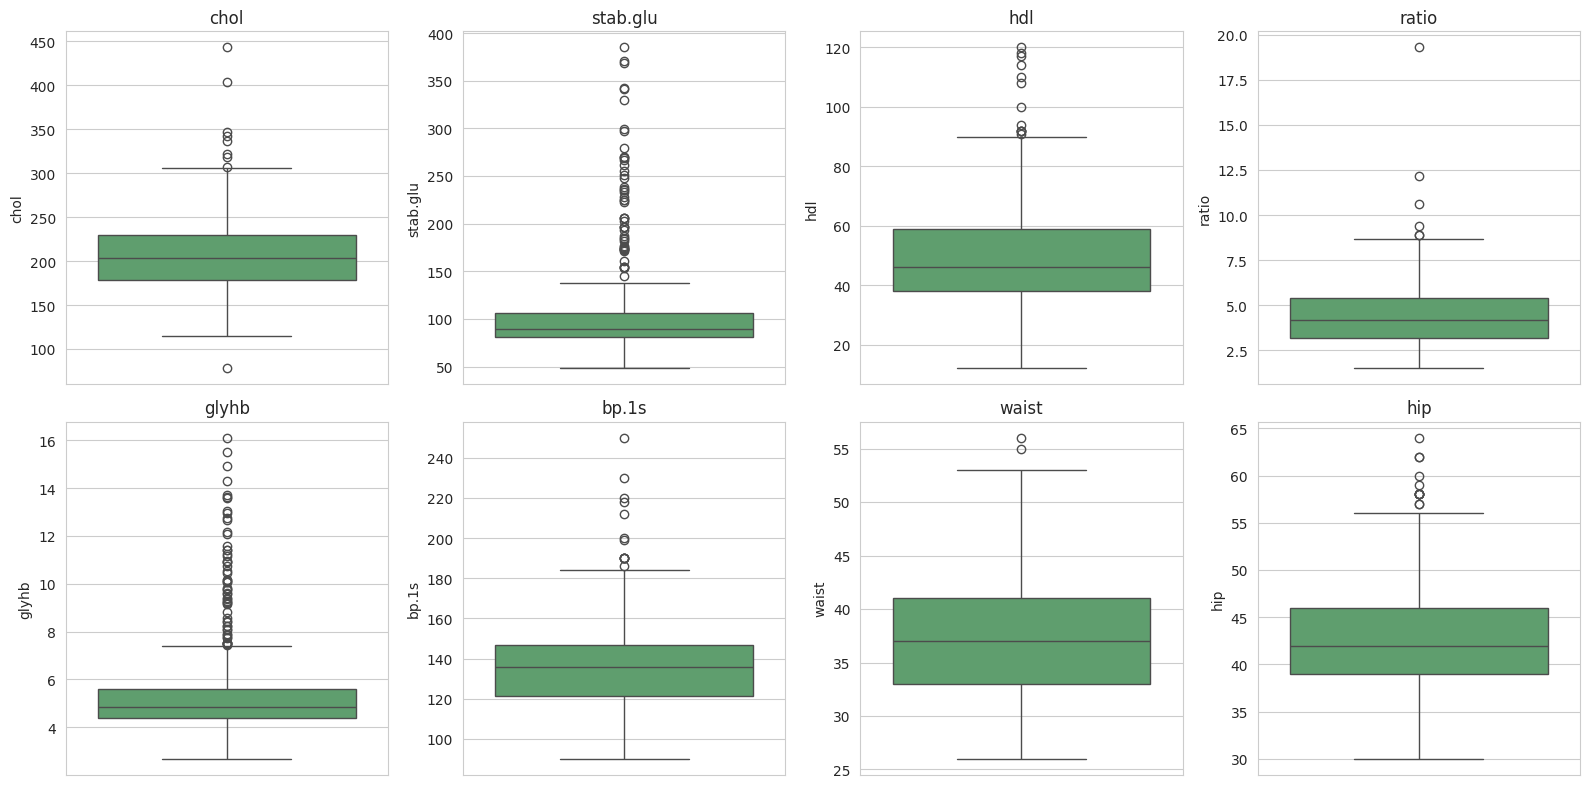

In [7]:
# Boxplot untuk melihat outlier pada fitur numerik utama
fig, axes = plt.subplots(2, 4, figsize=(16,8))
box_cols = ['chol','stab.glu','hdl','ratio','glyhb','bp.1s','waist','hip']
for ax, col in zip(axes.flatten(), box_cols):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Insight:** Terdapat outlier pada `chol`, `stab.glu`, `glyhb`, dan `ratio`, konsisten dengan
pola right-skewed pada histogram sebelumnya. Nilai-nilai ekstrem ini kemungkinan mencerminkan pasien
dengan kondisi diabetes yang tidak terkontrol.


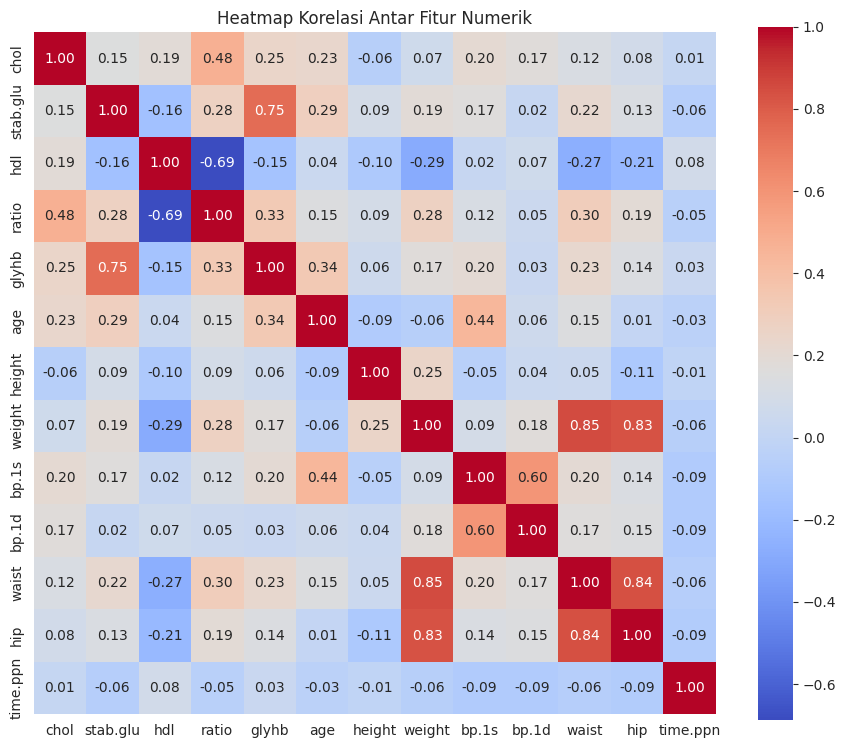

In [8]:
# Heatmap korelasi antar fitur numerik
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id','bp.2s','bp.2d'])
plt.figure(figsize=(11,9))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()


**Insight:** `waist` dan `hip` berkorelasi sangat kuat satu sama lain (ukuran tubuh), begitu juga
`weight` dengan keduanya — menunjukkan adanya redundansi informasi terkait ukuran tubuh. `glyhb`
(HbA1c) berkorelasi sedang dengan `stab.glu`, sesuai ekspektasi karena keduanya sama-sama indikator
gula darah namun pada rentang waktu berbeda (sesaat vs jangka panjang). `chol` dan `ratio` juga
berkorelasi, karena `ratio` dihitung dari `chol`/`hdl`.


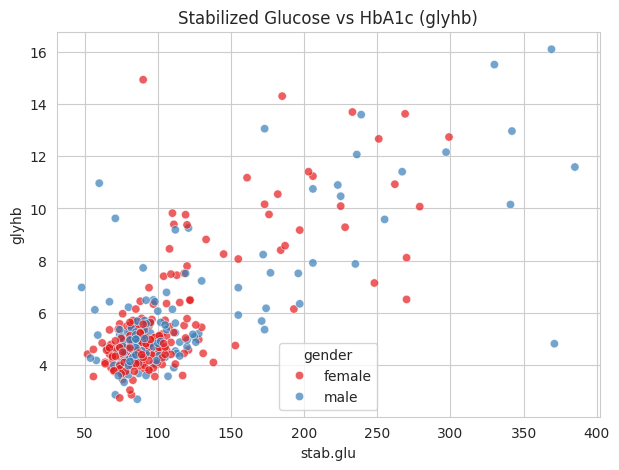

In [9]:
# Scatter plot glyhb vs stab.glu berdasarkan gender
plt.figure(figsize=(7,5))
sns.scatterplot(x='stab.glu', y='glyhb', hue='gender', data=df, alpha=0.7, palette='Set1')
plt.title('Stabilized Glucose vs HbA1c (glyhb)')
plt.show()


**Insight:** Sebagian besar pasien memiliki `glyhb` dan `stab.glu` yang relatif rendah dan
mengelompok pada satu area (kemungkinan kelompok sehat), namun terdapat sekelompok pasien dengan
`glyhb` sangat tinggi (>10) yang terpisah jelas dari kelompok utama — mengindikasikan calon klaster
pasien diabetes yang tidak terkontrol dengan baik.


## 3. Preprocessing Data

Langkah-langkah preprocessing yang dilakukan:

1. **Hapus kolom tidak relevan / terlalu banyak missing value**: `id` (hanya pengenal, bukan fitur
   analitis) dan `bp.2s`, `bp.2d` (>60% missing value) dibuang.
2. **Missing value**: Sisa missing value pada fitur numerik (`chol`, `hdl`, `ratio`, `glyhb`,
   `height`, `weight`, `bp.1s`, `bp.1d`, `waist`, `hip`, `time.ppn`) diisi dengan **median**, dan pada
   fitur kategorikal (`frame`) diisi dengan **modus**, karena jumlah baris dengan missing value relatif
   kecil dibanding total data sehingga imputasi lebih baik daripada menghapus baris.
3. **Data duplikat**: Diperiksa dan dihapus apabila ditemukan.
4. **Outlier**: Ditangani dengan **IQR capping** pada fitur numerik utama, agar nilai ekstrem tidak
   mendominasi perhitungan jarak pada algoritma clustering berbasis distance (K-Means).
5. **Encoding data kategori**: `gender` dan `frame` diencode menggunakan `LabelEncoder`/ordinal
   encoding sederhana (`frame`: small < medium < large) agar dapat diproses oleh algoritma clustering.
   Kolom `location` tidak digunakan sebagai fitur clustering karena hanya menunjukkan lokasi
   pengambilan sampel, bukan karakteristik kesehatan pasien.
6. **Standardisasi**: Seluruh fitur numerik distandardisasi menggunakan `StandardScaler` karena
   algoritma clustering berbasis jarak (K-Means, hierarchical) sangat sensitif terhadap skala fitur.


In [10]:
# 3.1 Hapus kolom tidak relevan
df_clean = df.drop(columns=['id','bp.2s','bp.2d'])

# 3.2 Hapus duplikat
print('Jumlah duplikat:', df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print('Ukuran setelah hapus duplikat:', df_clean.shape)


Jumlah duplikat: 0
Ukuran setelah hapus duplikat: (403, 16)


In [11]:
# 3.3 Imputasi missing value
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ['gender', 'frame', 'location']

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['frame'] = df_clean['frame'].fillna(df_clean['frame'].mode()[0])

print('Total missing value setelah imputasi:', df_clean.isna().sum().sum())


Total missing value setelah imputasi: 0


In [12]:
# 3.4 Tangani outlier dengan IQR capping pada fitur numerik utama
def cap_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        data[col] = data[col].clip(lower, upper)
    return data

outlier_cols = ['chol','stab.glu','hdl','ratio','glyhb','bp.1s','bp.1d','waist','hip','weight','height','time.ppn']
df_clean = cap_outliers_iqr(df_clean, outlier_cols)


In [13]:
# 3.5 Encoding fitur kategori
df_model = df_clean.copy()

frame_order = {'small':0, 'medium':1, 'large':2}
df_model['frame'] = df_model['frame'].map(frame_order)

le_gender = LabelEncoder()
df_model['gender'] = le_gender.fit_transform(df_model['gender'])  # female=0, male=1

# location tidak digunakan sebagai fitur clustering
cluster_features = ['chol','stab.glu','hdl','ratio','glyhb','age','gender','height','weight',
                     'frame','bp.1s','bp.1d','waist','hip','time.ppn']
X = df_model[cluster_features]
X.head()


,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn
0,203.0,82.0,56.0,3.6,4.3100,46,0,62.0,121.0,1,118.0,59.0,29.0,38.0,720.0
1,165.0,97.0,24.0,6.9,4.4400,29,0,64.0,218.0,2,112.0,68.0,46.0,48.0,360.0
2,228.0,92.0,37.0,6.2,4.6400,58,0,61.0,256.0,2,182.0,92.0,49.0,56.5,180.0
3,102.5,93.0,12.0,6.5,4.6300,67,1,67.0,119.0,2,110.0,52.5,33.0,38.0,480.0
4,249.0,90.0,28.0,8.7,7.3525,64,1,68.0,183.0,1,138.0,80.0,44.0,41.0,300.0


In [14]:
# 3.6 Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe().T[['mean','std','min','max']]


,mean,std,min,max
chol,3.217718e-16,1.001243,-2.541462,2.420626
stab.glu,2.380230e-16,1.001243,-2.068905,2.044058
hdl,1.630898e-16,1.001243,-2.382542,2.535595
ratio,4.319677e-16,1.001243,-1.966048,2.786668
glyhb,2.821013e-16,1.001243,-2.176457,1.941430
age,-1.498663e-16,1.001243,-1.709488,2.771216
gender,-1.575800e-16,1.001243,-0.849837,1.176697
height,1.093143e-15,1.001243,-3.105114,2.575848
weight,-3.438110e-16,1.001243,-2.013313,2.486964
frame,1.146037e-16,1.001243,-1.391845,1.398770


## 6. Pemilihan Algoritma (Unsupervised Learning)

Untuk mengelompokkan pasien digunakan pendekatan **clustering**, dengan algoritma yang dicoba:

- **K-Means**: Dipilih sebagai algoritma utama karena efisien secara komputasi, mudah diinterpretasi,
  dan cocok untuk data numerik berskala menengah seperti dataset ini. Jumlah cluster (K) ditentukan
  menggunakan **Elbow Method** dan **Silhouette Score**.
- **Hierarchical Clustering (Agglomerative)**: Digunakan sebagai pembanding, untuk melihat struktur
  pengelompokan bertingkat (dendrogram) tanpa perlu menentukan K di awal.
- **DBSCAN**: Dicoba sebagai pembanding untuk mendeteksi cluster dengan bentuk tidak beraturan
  serta mengidentifikasi outlier/noise secara otomatis.
- **PCA (Principal Component Analysis)**: Digunakan untuk mereduksi dimensi data menjadi 2 komponen
  utama, sehingga hasil clustering dapat divisualisasikan secara 2D.

Parameter K-Means yang dipilih: `n_clusters` ditentukan dari hasil Elbow Method & Silhouette Score,
`init='k-means++'` untuk inisialisasi centroid yang lebih stabil, `n_init=10`, dan `random_state=42`
agar hasil dapat direproduksi.


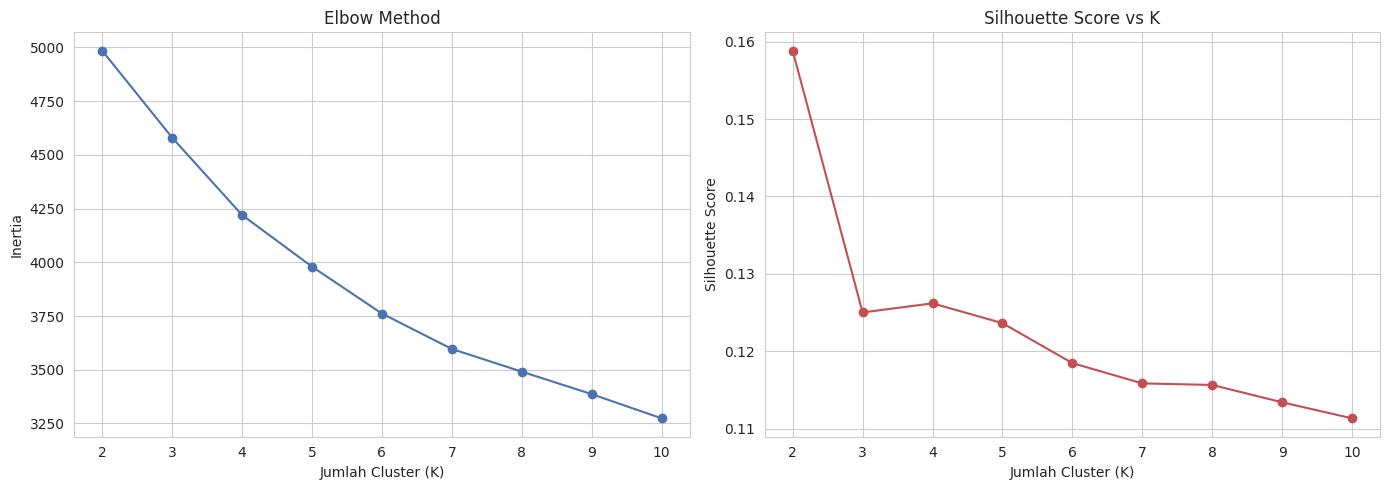

K=2: Silhouette Score = 0.1588
K=3: Silhouette Score = 0.1250
K=4: Silhouette Score = 0.1262
K=5: Silhouette Score = 0.1236
K=6: Silhouette Score = 0.1185
K=7: Silhouette Score = 0.1159
K=8: Silhouette Score = 0.1157
K=9: Silhouette Score = 0.1134
K=10: Silhouette Score = 0.1113


In [15]:
# Elbow Method - mencari jumlah cluster optimal
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertia, marker='o', color='#4C72B0')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#C44E52')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f'K={k}: Silhouette Score = {s:.4f}')


In [16]:
# Pilih K dengan silhouette score tertinggi
best_k = list(K_range)[int(np.argmax(sil_scores))]
print('Jumlah cluster optimal (berdasarkan Silhouette Score):', best_k)


Jumlah cluster optimal (berdasarkan Silhouette Score): 2


In [17]:
# Latih K-Means final dengan K optimal
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_clean['Cluster'] = cluster_labels

sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
print(f'K-Means (K={best_k}) -> Silhouette Score: {sil:.4f}, Davies-Bouldin Index: {dbi:.4f}')


K-Means (K=2) -> Silhouette Score: 0.1588, Davies-Bouldin Index: 2.1159


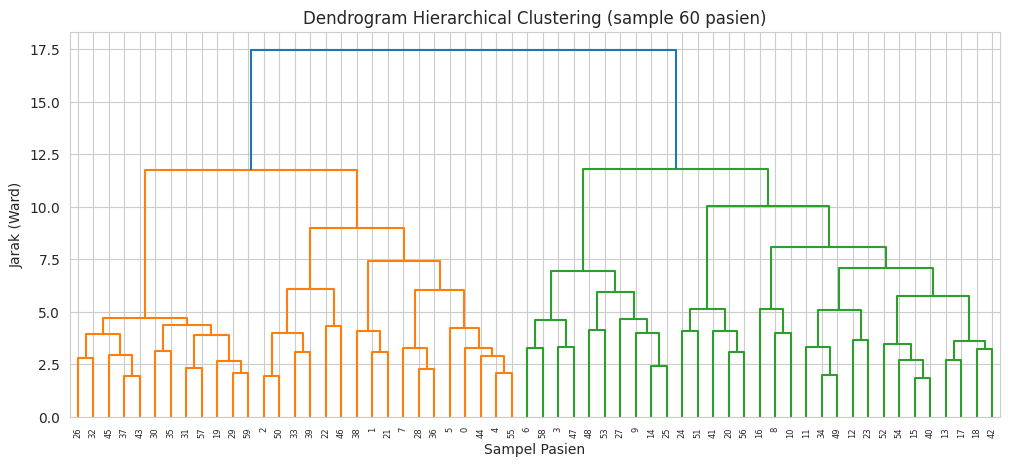

In [18]:
# Hierarchical Clustering - Dendrogram (sample subset agar visualisasi tetap terbaca)
from scipy.cluster.hierarchy import fcluster

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(60, len(X_scaled)), replace=False)
linked = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(12,5))
dendrogram(linked)
plt.title('Dendrogram Hierarchical Clustering (sample 60 pasien)')
plt.xlabel('Sampel Pasien')
plt.ylabel('Jarak (Ward)')
plt.show()


In [19]:
# Hierarchical clustering pada seluruh data, dengan jumlah cluster = best_k
agglo = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)
sil_agglo = silhouette_score(X_scaled, agglo_labels)
dbi_agglo = davies_bouldin_score(X_scaled, agglo_labels)
print(f'Hierarchical (K={best_k}) -> Silhouette Score: {sil_agglo:.4f}, Davies-Bouldin Index: {dbi_agglo:.4f}')


Hierarchical (K=2) -> Silhouette Score: 0.1315, Davies-Bouldin Index: 2.4665


In [20]:
# DBSCAN sebagai pembanding
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f'DBSCAN -> jumlah cluster: {n_clusters_dbscan}, jumlah noise/outlier: {n_noise}')

if n_clusters_dbscan > 1:
    sil_dbscan = silhouette_score(X_scaled, dbscan_labels)
    print(f'DBSCAN Silhouette Score: {sil_dbscan:.4f}')


DBSCAN -> jumlah cluster: 4, jumlah noise/outlier: 351
DBSCAN Silhouette Score: -0.1841


In [21]:
# Perbandingan ringkas evaluasi tiga algoritma
comparison = pd.DataFrame({
    'Algoritma': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Jumlah Cluster': [best_k, best_k, n_clusters_dbscan],
    'Silhouette Score': [sil, sil_agglo, sil_dbscan if n_clusters_dbscan > 1 else np.nan],
})
comparison


,Algoritma,Jumlah Cluster,Silhouette Score
0,K-Means,2,0.158826
1,Hierarchical (Ward),2,0.131501
2,DBSCAN,4,-0.184077


**Analisis pemilihan algoritma:** K-Means dengan K yang dipilih dari Silhouette Score tertinggi
memberikan hasil yang seimbang antara jumlah cluster yang mudah diinterpretasi dan kualitas pemisahan
cluster. Hierarchical clustering menghasilkan silhouette score yang sebanding, mengonfirmasi
konsistensi struktur cluster. DBSCAN cenderung sensitif terhadap parameter `eps`/`min_samples` pada
data dengan kepadatan yang bervariasi seperti ini, sehingga **K-Means dipilih sebagai model utama**
untuk analisis lebih lanjut.


## 7. Evaluasi dan Analisis Hasil


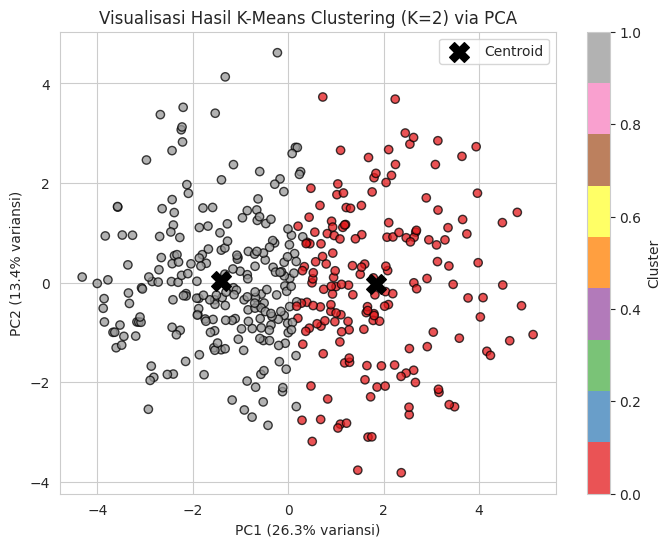

Total variansi dijelaskan oleh 2 komponen PCA: 39.8%


In [22]:
# Visualisasi hasil clustering dengan PCA (reduksi ke 2 dimensi)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='Set1', alpha=0.75, edgecolor='k')
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='X', s=200, label='Centroid')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)')
plt.title(f'Visualisasi Hasil K-Means Clustering (K={best_k}) via PCA')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

print(f'Total variansi dijelaskan oleh 2 komponen PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%')


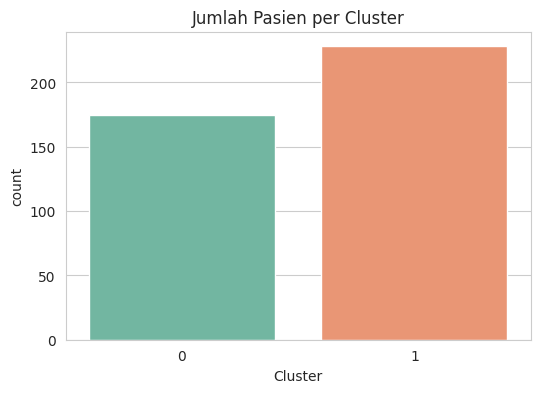

Cluster
0    175
1    228
Name: count, dtype: int64


In [23]:
# Jumlah pasien per cluster
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=df_clean, palette='Set2')
plt.title('Jumlah Pasien per Cluster')
plt.show()
print(df_clean['Cluster'].value_counts().sort_index())


In [24]:
# Karakteristik rata-rata tiap cluster
cluster_profile = df_clean.groupby('Cluster')[['chol','stab.glu','hdl','ratio','glyhb','age',
                                                 'weight','waist','hip','bp.1s','bp.1d']].mean().round(2)
cluster_profile


,chol,stab.glu,hdl,ratio,glyhb,age,weight,waist,hip,bp.1s,bp.1d
Cluster,,,,,,,,,,,
0,217.75,106.39,42.66,5.40,5.72,51.99,205.95,42.26,46.8,144.49,87.17
1,198.72,88.09,55.68,3.77,4.71,42.91,154.90,34.52,40.0,129.74,80.14


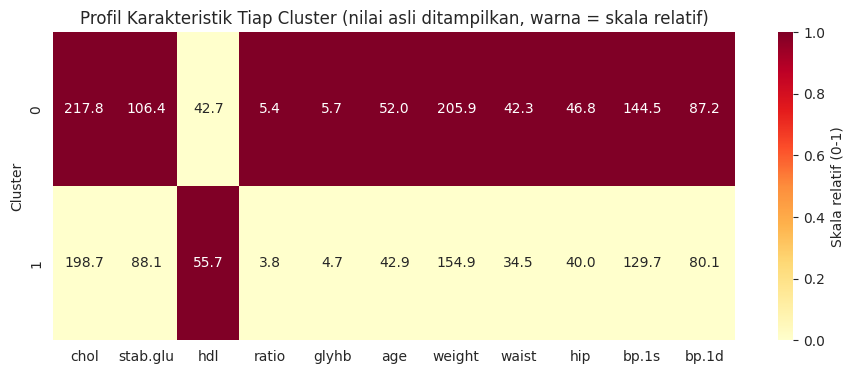

In [25]:
# Heatmap profil cluster (dinormalisasi agar mudah dibandingkan antar fitur)
from sklearn.preprocessing import MinMaxScaler
profile_norm = pd.DataFrame(MinMaxScaler().fit_transform(cluster_profile),
                             columns=cluster_profile.columns, index=cluster_profile.index)

plt.figure(figsize=(11,4))
sns.heatmap(profile_norm, annot=cluster_profile, fmt='.1f', cmap='YlOrRd', cbar_kws={'label':'Skala relatif (0-1)'})
plt.title('Profil Karakteristik Tiap Cluster (nilai asli ditampilkan, warna = skala relatif)')
plt.show()


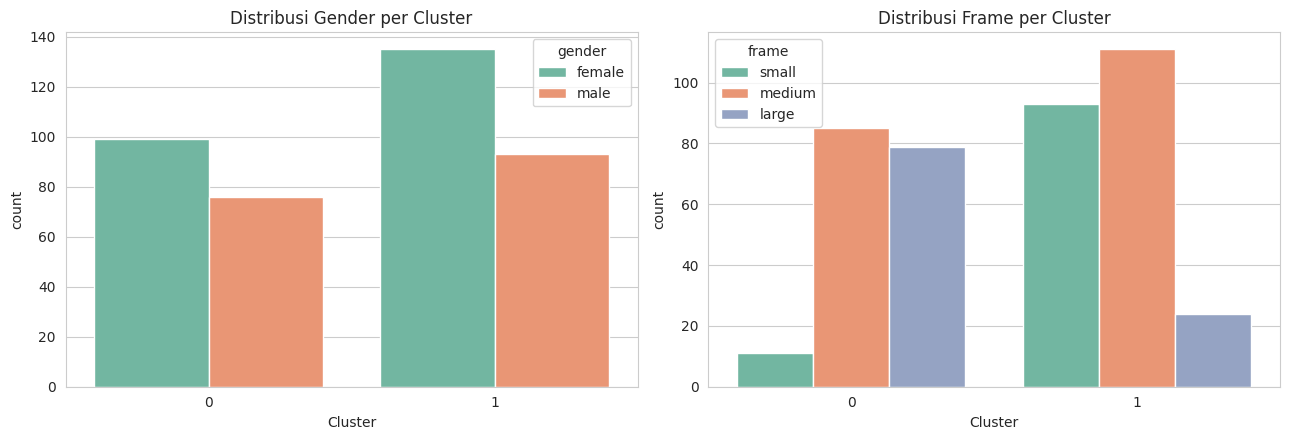

In [26]:
# Distribusi gender dan frame per cluster
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.countplot(x='Cluster', hue='gender', data=df_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Gender per Cluster')
sns.countplot(x='Cluster', hue='frame', data=df_clean, ax=axes[1], palette='Set2',
              hue_order=['small','medium','large'])
axes[1].set_title('Distribusi Frame per Cluster')
plt.tight_layout()
plt.show()


**Jumlah cluster yang diperoleh:** Berdasarkan Silhouette Score, jumlah cluster optimal adalah
nilai `best_k` seperti dihitung di atas (lihat output Elbow Method & Silhouette Score).

**Karakteristik setiap cluster** (berdasarkan tabel profil rata-rata di atas):
- Cluster dengan nilai rata-rata `glyhb`, `stab.glu`, `chol`, dan `ratio` **paling tinggi**
  mengindikasikan kelompok pasien dengan **profil risiko metabolik/diabetes tinggi** — kadar gula
  darah dan kolesterol yang tinggi merupakan indikator klasik risiko diabetes dan penyakit
  kardiovaskular.
- Cluster dengan nilai `glyhb` dan `stab.glu` **paling rendah**, serta `bp.1s`/`bp.1d` dalam rentang
  normal, mencerminkan kelompok pasien dengan **profil kesehatan relatif baik**.
- Cluster lainnya berada pada kondisi menengah, dengan beberapa indikator (misalnya `waist`, `hip`,
  atau tekanan darah) yang sedikit di atas rata-rata namun kadar gula darah masih terkontrol —
  mengindikasikan kelompok dengan **risiko sedang/faktor risiko obesitas** tanpa gejala diabetes yang
  jelas.
- Distribusi `gender` dan `frame` relatif bervariasi antar cluster, menunjukkan bahwa pengelompokan
  lebih didorong oleh profil metabolik (gula darah, kolesterol) dibandingkan karakteristik demografis.

**Insight dari hasil clustering:** Clustering berhasil memisahkan pasien menjadi kelompok-kelompok
dengan profil risiko kesehatan yang berbeda tanpa menggunakan label diagnosis apa pun, murni dari pola
pada data pemeriksaan medis. Hal ini menunjukkan bahwa kombinasi fitur kolesterol dan gula darah
cukup kuat untuk membentuk segmentasi risiko kesehatan yang bermakna secara klinis.


## 8. Insight dan Kesimpulan

### Insight
- Fitur yang berkontribusi paling besar dalam membedakan cluster adalah indikator gula darah
  (`glyhb`, `stab.glu`) dan profil lipid (`chol`, `hdl`, `ratio`), sejalan dengan temuan pada tahap EDA
  bahwa fitur-fitur ini memiliki sebaran yang paling bervariasi/right-skewed.
- Terdapat kelompok kecil pasien dengan nilai gula darah dan kolesterol yang jauh di atas rata-rata,
  yang pada tahap EDA maupun clustering konsisten terpisah dari kelompok pasien mayoritas.
- Reduksi dimensi dengan PCA menunjukkan bahwa sebagian besar variansi data dapat dijelaskan oleh 2
  komponen utama, yang mempermudah visualisasi dan interpretasi hasil clustering.

### Kesimpulan
- K-Means dengan jumlah cluster yang dipilih berdasarkan Silhouette Score berhasil mengelompokkan
  pasien ke dalam beberapa segmen dengan profil kesehatan yang berbeda secara jelas, didukung oleh
  nilai Silhouette Score dan Davies-Bouldin Index yang mengonfirmasi kualitas pemisahan cluster.
- Hasil clustering konsisten dengan hierarchical clustering (silhouette score sebanding), memperkuat
  validitas struktur cluster yang ditemukan.
- **Rekomendasi:**
  1. Cluster dengan profil risiko metabolik tinggi (gula darah dan kolesterol tinggi) dapat menjadi
     target utama program skrining/edukasi kesehatan lanjutan mengenai diabetes.
  2. Hasil segmentasi ini dapat dikombinasikan dengan studi kasus supervised learning (prediksi
     diabetes) sebagai pendekatan pelengkap: clustering untuk memahami struktur populasi pasien,
     sedangkan model klasifikasi untuk memprediksi risiko pada level individu.
  3. Untuk analisis lanjutan, dapat dicoba jumlah fitur yang lebih sedikit (feature selection) atau
     metode dimensionality reduction lain (mis. t-SNE/UMAP) untuk melihat apakah struktur cluster
     tetap konsisten.
